<a href="https://colab.research.google.com/github/FranciscodeVigil/DATASCI507_Repo/blob/main/STATS507_FinalProject_FVigil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Car make CNN classification
There has been lots of effort to do full clasification of make and model using CNN architecture however I have seen very little investigation of the make, their may be some ability for a CNN to recognize comonalities between makes and accelerate the task when more robust architecture and compute is unavailible.

This has all of the model and data loading then a section at the end where the visuals from the project are recreated using the data saved from my trained model.

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.models as models
import torchvision.transforms as transforms

from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR

from PIL import Image

from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt

In [4]:
!git clone https://github.com/FranciscodeVigil/Stats507Project.git

Cloning into 'Stats507Project'...


## Loading the Standford car dataset:
The standford image dataset is the standard for many make and model vehicle image classification tasks. This makes it perfect for the task but the base format needs pre processing.

In [1]:
!git clone https://github.com/cyizhuo/Stanford_Cars_dataset.git

Cloning into 'Stanford_Cars_dataset'...
remote: Enumerating objects: 16581, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
^C


# Categorical Analysis:
We want to find the total number of makes and the number of classes per make so we can get a better idea of the structure of our dataset.

In [3]:
# Here are the 5 two word and hyphenated makes just to handle seperately
TWO_WORD_MAKES = [
    'AM General', 'Aston Martin', 'Land Rover',
    'Rolls-Royce', 'Mercedes-Benz'
]

def extract_make(folder_name):
    for make in TWO_WORD_MAKES:
        if folder_name.startswith(make):
            return make
    return folder_name.split()[0]

# Get all class folder names from train
train_path = 'Stanford_Cars_dataset/train'
class_folders = os.listdir(train_path)

# Extract makes
makes = sorted(set(extract_make(f) for f in class_folders))

print(f"Total unique makes: {len(makes)}")
for make in makes:
    count = sum(1 for f in class_folders if extract_make(f) == make)
    print(f"  {make}: {count} classes")

Total unique makes: 49
  AM General: 1 classes
  Acura: 6 classes
  Aston Martin: 4 classes
  Audi: 14 classes
  BMW: 13 classes
  Bentley: 6 classes
  Bugatti: 2 classes
  Buick: 4 classes
  Cadillac: 3 classes
  Chevrolet: 22 classes
  Chrysler: 6 classes
  Daewoo: 1 classes
  Dodge: 15 classes
  Eagle: 1 classes
  FIAT: 2 classes
  Ferrari: 4 classes
  Fisker: 1 classes
  Ford: 12 classes
  GMC: 5 classes
  Geo: 1 classes
  HUMMER: 2 classes
  Honda: 4 classes
  Hyundai: 11 classes
  Infiniti: 2 classes
  Isuzu: 1 classes
  Jaguar: 1 classes
  Jeep: 5 classes
  Lamborghini: 4 classes
  Land Rover: 2 classes
  Lincoln: 1 classes
  MINI: 1 classes
  Maybach: 1 classes
  Mazda: 1 classes
  McLaren: 1 classes
  Mercedes-Benz: 6 classes
  Mitsubishi: 1 classes
  Nissan: 4 classes
  Plymouth: 1 classes
  Porsche: 1 classes
  Ram: 1 classes
  Rolls-Royce: 3 classes
  Scion: 1 classes
  Spyker: 2 classes
  Suzuki: 4 classes
  Tesla: 1 classes
  Toyota: 4 classes
  Volkswagen: 3 classes
  Vo

Now we also want to see how many images are avalible for each class so we can see if there are classes without much data avalible.

In [4]:
def count_images(base_path, class_folders, make):
    total = 0
    for folder in class_folders:
        if extract_make(folder) == make:
            folder_path = os.path.join(base_path, folder)
            total += len(os.listdir(folder_path))
    return total

for make in makes:
    img_count = count_images(train_path, class_folders, make)
    print(f"  {make}: {img_count} images")

  AM General: 45 images
  Acura: 242 images
  Aston Martin: 157 images
  Audi: 589 images
  BMW: 531 images
  Bentley: 238 images
  Bugatti: 77 images
  Buick: 158 images
  Cadillac: 129 images
  Chevrolet: 905 images
  Chrysler: 260 images
  Daewoo: 45 images
  Dodge: 630 images
  Eagle: 46 images
  FIAT: 62 images
  Ferrari: 164 images
  Fisker: 44 images
  Ford: 521 images
  GMC: 238 images
  Geo: 45 images
  HUMMER: 83 images
  Honda: 161 images
  Hyundai: 438 images
  Infiniti: 67 images
  Isuzu: 40 images
  Jaguar: 47 images
  Jeep: 220 images
  Lamborghini: 161 images
  Land Rover: 86 images
  Lincoln: 39 images
  MINI: 37 images
  Maybach: 29 images
  Mazda: 36 images
  McLaren: 44 images
  Mercedes-Benz: 261 images
  Mitsubishi: 48 images
  Nissan: 171 images
  Plymouth: 44 images
  Porsche: 44 images
  Ram: 41 images
  Rolls-Royce: 114 images
  Scion: 42 images
  Spyker: 88 images
  Suzuki: 167 images
  Tesla: 39 images
  Toyota: 168 images
  Volkswagen: 132 images
  Volvo: 1

We see that there are a few categories with very few images avalible, inorder to remove data avalibility concerns, based on the images avalible it seems like 60 is a good bound to keep some more unique brands (Hummer, Bugati, FIAT) while also remmoving makes with limited data.

In [5]:
# Filter makes with 60+ images
MIN_IMAGES = 60

make_image_counts = {make: count_images(train_path, class_folders, make) for make in makes}

valid_makes = sorted([make for make, count in make_image_counts.items() if count >= MIN_IMAGES])

print(f"Total makes kept: {len(valid_makes)}")
for make in valid_makes:
    print(f"  {make}: {make_image_counts[make]} images")

Total makes kept: 30
  Acura: 242 images
  Aston Martin: 157 images
  Audi: 589 images
  BMW: 531 images
  Bentley: 238 images
  Bugatti: 77 images
  Buick: 158 images
  Cadillac: 129 images
  Chevrolet: 905 images
  Chrysler: 260 images
  Dodge: 630 images
  FIAT: 62 images
  Ferrari: 164 images
  Ford: 521 images
  GMC: 238 images
  HUMMER: 83 images
  Honda: 161 images
  Hyundai: 438 images
  Infiniti: 67 images
  Jeep: 220 images
  Lamborghini: 161 images
  Land Rover: 86 images
  Mercedes-Benz: 261 images
  Nissan: 171 images
  Rolls-Royce: 114 images
  Spyker: 88 images
  Suzuki: 167 images
  Toyota: 168 images
  Volkswagen: 132 images
  Volvo: 131 images


In [6]:
# Create make to index mapping
make_to_idx = {make: idx for idx, make in enumerate(valid_makes)}
idx_to_make = {idx: make for make, idx in make_to_idx.items()}

print(f"\nMake to index mapping:")
for make, idx in make_to_idx.items():
    print(f"  {idx}: {make}")


Make to index mapping:
  0: Acura
  1: Aston Martin
  2: Audi
  3: BMW
  4: Bentley
  5: Bugatti
  6: Buick
  7: Cadillac
  8: Chevrolet
  9: Chrysler
  10: Dodge
  11: FIAT
  12: Ferrari
  13: Ford
  14: GMC
  15: HUMMER
  16: Honda
  17: Hyundai
  18: Infiniti
  19: Jeep
  20: Lamborghini
  21: Land Rover
  22: Mercedes-Benz
  23: Nissan
  24: Rolls-Royce
  25: Spyker
  26: Suzuki
  27: Toyota
  28: Volkswagen
  29: Volvo


Make a class in order to load the data more efficiently, per Claude AI's recomendation.

In [7]:

class StanfordMakeDataset(Dataset):
    def __init__(self, root_dir, make_to_idx, transform=None):
        self.transform = transform
        self.make_to_idx = make_to_idx
        self.samples = []

        for class_folder in os.listdir(root_dir):
            make = extract_make(class_folder)
            if make not in make_to_idx:
                continue
            folder_path = os.path.join(root_dir, class_folder)
            for img_file in os.listdir(folder_path):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((
                        os.path.join(folder_path, img_file),
                        make_to_idx[make]
                    ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

In [8]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = StanfordMakeDataset('Stanford_Cars_dataset/train', make_to_idx, train_transforms)
test_dataset = StanfordMakeDataset('Stanford_Cars_dataset/test', make_to_idx, test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 7349
Test samples: 7255


We cannot rely on the bare CNN model to achive accurate results because there are still basic image recognition skills which a pretrained net like IMAGE NET can provide to increase overall accuracy of the classifier.

In [9]:
# Load pretrained MobileNetV2
model = models.mobilenet_v2(weights='IMAGENET1K_V1')

# Freeze all backbone weights
for param in model.parameters():
    param.requires_grad = False

# Replace the classifier head for 30 classes
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(model.last_channel, 30)
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Using device: {device}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 177MB/s]


Using device: cuda
Trainable parameters: 38430


Make training weights based on the inverse of the number of files in each label.

In [10]:

class_counts = [0] * 30
for _, label in train_dataset.samples:
    class_counts[label] += 1

class_weights = torch.tensor([1.0 / c for c in class_counts], dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

Do the actual stage 1 learning.

In [11]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

#Phase 1 Frozen Train:

NUM_EPOCHS = 10
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = eval_epoch(model, test_loader, criterion, device)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} "
          f"| Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.1f}% "
          f"| Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.1f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model_phase1.pth')

print(f"\nBest validation accuracy: {best_val_acc:.1f}%")

Epoch 1/10 | Train Loss: 2.811 | Train Acc: 18.2% | Val Loss: 2.528 | Val Acc: 24.4%
Epoch 2/10 | Train Loss: 2.129 | Train Acc: 32.7% | Val Loss: 2.136 | Val Acc: 37.8%
Epoch 3/10 | Train Loss: 1.855 | Train Acc: 37.9% | Val Loss: 1.984 | Val Acc: 40.4%
Epoch 4/10 | Train Loss: 1.728 | Train Acc: 40.6% | Val Loss: 1.936 | Val Acc: 41.8%
Epoch 5/10 | Train Loss: 1.643 | Train Acc: 42.8% | Val Loss: 1.935 | Val Acc: 40.4%
Epoch 6/10 | Train Loss: 1.561 | Train Acc: 44.0% | Val Loss: 1.920 | Val Acc: 40.6%
Epoch 7/10 | Train Loss: 1.522 | Train Acc: 45.1% | Val Loss: 1.826 | Val Acc: 44.0%
Epoch 8/10 | Train Loss: 1.457 | Train Acc: 46.9% | Val Loss: 1.855 | Val Acc: 43.6%
Epoch 9/10 | Train Loss: 1.422 | Train Acc: 47.2% | Val Loss: 1.894 | Val Acc: 41.4%
Epoch 10/10 | Train Loss: 1.410 | Train Acc: 47.4% | Val Loss: 1.824 | Val Acc: 44.6%

Best validation accuracy: 44.6%


In [12]:
# Phase 2 Whole Train:
for param in model.parameters():
    param.requires_grad = True

# Lower learning rate to avoid damaging pretrained weights
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

# Load best weights
model.load_state_dict(torch.load('best_model_phase1.pth'))

best_val_acc = 0.0

NUM_EPOCHS = 15

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = eval_epoch(model, test_loader, criterion, device)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} "
          f"| Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.1f}% "
          f"| Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.1f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model_phase2.pth')

print(f"\nBest validation accuracy: {best_val_acc:.1f}%")

Epoch 1/15 | Train Loss: 1.132 | Train Acc: 56.8% | Val Loss: 1.142 | Val Acc: 62.9%
Epoch 2/15 | Train Loss: 0.585 | Train Acc: 73.6% | Val Loss: 0.936 | Val Acc: 69.5%
Epoch 3/15 | Train Loss: 0.357 | Train Acc: 82.4% | Val Loss: 0.801 | Val Acc: 73.7%
Epoch 4/15 | Train Loss: 0.232 | Train Acc: 87.7% | Val Loss: 0.733 | Val Acc: 77.1%
Epoch 5/15 | Train Loss: 0.154 | Train Acc: 92.3% | Val Loss: 0.694 | Val Acc: 78.9%
Epoch 6/15 | Train Loss: 0.109 | Train Acc: 94.7% | Val Loss: 0.663 | Val Acc: 79.2%
Epoch 7/15 | Train Loss: 0.079 | Train Acc: 96.1% | Val Loss: 0.660 | Val Acc: 80.5%
Epoch 8/15 | Train Loss: 0.054 | Train Acc: 97.4% | Val Loss: 0.670 | Val Acc: 80.6%
Epoch 9/15 | Train Loss: 0.057 | Train Acc: 97.5% | Val Loss: 0.677 | Val Acc: 80.3%
Epoch 10/15 | Train Loss: 0.060 | Train Acc: 97.2% | Val Loss: 0.667 | Val Acc: 81.5%
Epoch 11/15 | Train Loss: 0.028 | Train Acc: 98.9% | Val Loss: 0.622 | Val Acc: 82.8%
Epoch 12/15 | Train Loss: 0.022 | Train Acc: 99.3% | Val Loss: 

Look at the per class break down.

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Load best model
model.load_state_dict(torch.load('best_model_phase2.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Per class report
print(classification_report(
    all_labels,
    all_preds,
    target_names=valid_makes
))

               precision    recall  f1-score   support

        Acura       0.80      0.80      0.80       240
 Aston Martin       0.85      0.87      0.86       157
         Audi       0.89      0.88      0.88       580
          BMW       0.89      0.89      0.89       524
      Bentley       0.92      0.91      0.91       234
      Bugatti       0.86      0.95      0.90        75
        Buick       0.85      0.84      0.84       156
     Cadillac       0.84      0.87      0.85       128
    Chevrolet       0.81      0.82      0.81       894
     Chrysler       0.83      0.79      0.81       256
        Dodge       0.83      0.83      0.83       623
         FIAT       0.85      0.92      0.88        60
      Ferrari       0.90      0.92      0.91       162
         Ford       0.80      0.80      0.80       514
          GMC       0.82      0.81      0.82       235
       HUMMER       0.94      0.90      0.92        82
        Honda       0.80      0.81      0.81       160
      Hyu

Visualize the recall and precision lable dataset size.

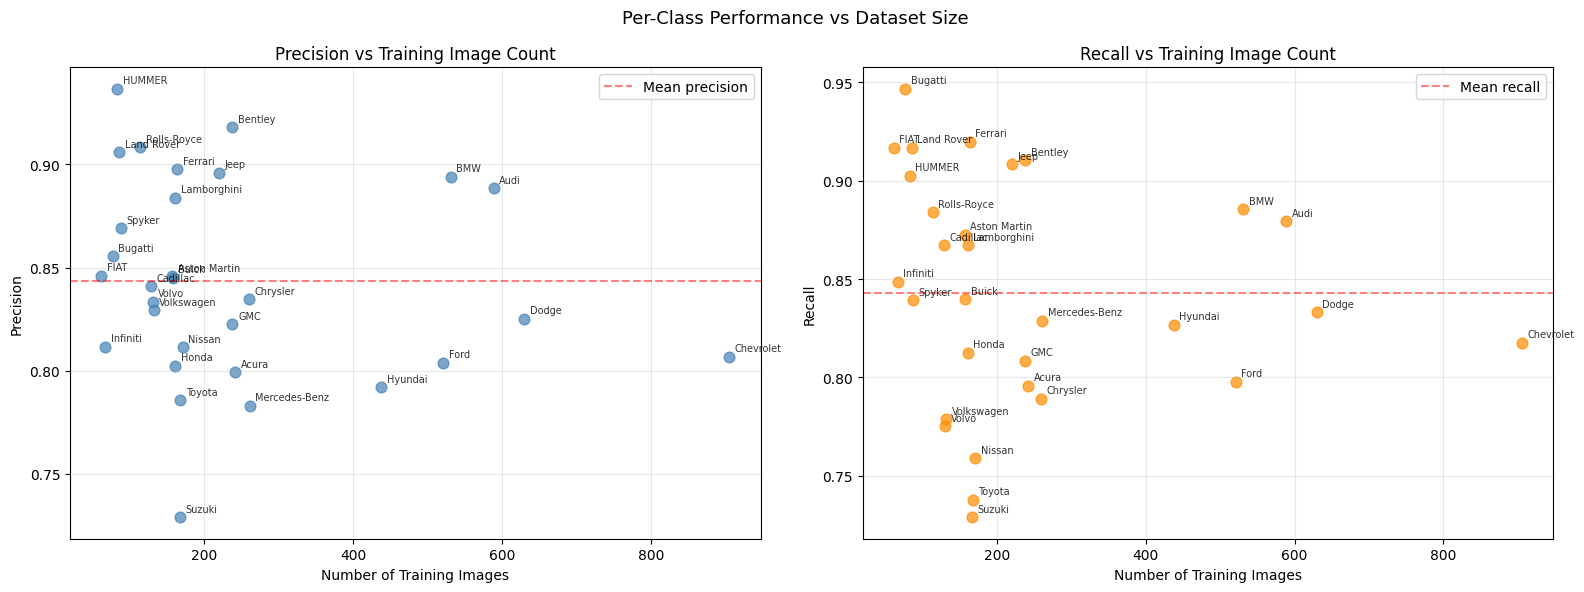

In [14]:
# Extract per-class metrics
report = classification_report(
    all_labels,
    all_preds,
    target_names=valid_makes,
    output_dict=True
)

precisions = [report[make]['precision'] for make in valid_makes]
recalls = [report[make]['recall'] for make in valid_makes]
image_counts = [make_image_counts[make] for make in valid_makes]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Precision vs image count
ax1.scatter(image_counts, precisions, alpha=0.7, color='steelblue', s=60)
for i, make in enumerate(valid_makes):
    ax1.annotate(make, (image_counts[i], precisions[i]),
                fontsize=7, alpha=0.8,
                xytext=(4, 4), textcoords='offset points')
ax1.set_xlabel('Number of Training Images')
ax1.set_ylabel('Precision')
ax1.set_title('Precision vs Training Image Count')
ax1.axhline(y=np.mean(precisions), color='red', linestyle='--', alpha=0.5, label='Mean precision')
ax1.legend()
ax1.grid(alpha=0.3)

# Recall vs image count
ax2.scatter(image_counts, recalls, alpha=0.7, color='darkorange', s=60)
for i, make in enumerate(valid_makes):
    ax2.annotate(make, (image_counts[i], recalls[i]),
                fontsize=7, alpha=0.8,
                xytext=(4, 4), textcoords='offset points')
ax2.set_xlabel('Number of Training Images')
ax2.set_ylabel('Recall')
ax2.set_title('Recall vs Training Image Count')
ax2.axhline(y=np.mean(recalls), color='red', linestyle='--', alpha=0.5, label='Mean recall')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Per-Class Performance vs Dataset Size', fontsize=13)
plt.tight_layout()
plt.savefig('precision_recall_vs_count.png', dpi=150)
plt.show()

In [9]:
data = {
    'class': [
        'Acura', 'Aston Martin', 'Audi', 'BMW', 'Bentley', 'Bugatti', 'Buick',
        'Cadillac', 'Chevrolet', 'Chrysler', 'Dodge', 'FIAT', 'Ferrari', 'Ford',
        'GMC', 'HUMMER', 'Honda', 'Hyundai', 'Infiniti', 'Jeep', 'Lamborghini',
        'Land Rover', 'Mercedes-Benz', 'Nissan', 'Rolls-Royce', 'Spyker',
        'Suzuki', 'Toyota', 'Volkswagen', 'Volvo'
    ],
    'precision': [
        0.80, 0.85, 0.89, 0.89, 0.92, 0.86, 0.85, 0.84, 0.81, 0.83, 0.83,
        0.85, 0.90, 0.80, 0.82, 0.94, 0.80, 0.79, 0.81, 0.90, 0.88, 0.91,
        0.78, 0.81, 0.91, 0.87, 0.73, 0.79, 0.83, 0.83
    ],
    'recall': [
        0.80, 0.87, 0.88, 0.89, 0.91, 0.95, 0.84, 0.87, 0.82, 0.79, 0.83,
        0.92, 0.92, 0.80, 0.81, 0.90, 0.81, 0.83, 0.85, 0.91, 0.87, 0.92,
        0.83, 0.76, 0.88, 0.84, 0.73, 0.74, 0.78, 0.78
    ],
    'f1_score': [
        0.80, 0.86, 0.88, 0.89, 0.91, 0.90, 0.84, 0.85, 0.81, 0.81, 0.83,
        0.88, 0.91, 0.80, 0.82, 0.92, 0.81, 0.81, 0.83, 0.90, 0.88, 0.91,
        0.81, 0.78, 0.90, 0.85, 0.73, 0.76, 0.80, 0.80
    ],
    'support': [
        240, 157, 580, 524, 234, 75, 156, 128, 894, 256, 623, 60, 162, 514,
        235, 82, 160, 433, 66, 218, 158, 84, 257, 170, 112, 87, 166, 164,
        131, 129
    ],
    'num_models': [
        4, 8, 8, 8, 5, 1, 3, 3, 16, 4, 8, 1, 5, 8,
        4, 2, 3, 7, 2, 4, 3, 2, 6, 5, 3, 2, 3, 5, 4, 3
    ]
}

df = pd.DataFrame(data)

In [5]:
class_distribution = {
    'Acura': 242,
    'Aston Martin': 157,
    'Audi': 589,
    'BMW': 531,
    'Bentley': 238,
    'Bugatti': 77,
    'Buick': 158,
    'Cadillac': 129,
    'Chevrolet': 905,
    'Chrysler': 260,
    'Dodge': 630,
    'FIAT': 62,
    'Ferrari': 164,
    'Ford': 521,
    'GMC': 238,
    'HUMMER': 83,
    'Honda': 161,
    'Hyundai': 438,
    'Infiniti': 67,
    'Jeep': 220,
    'Lamborghini': 161,
    'Land Rover': 86,
    'Mercedes-Benz': 261,
    'Nissan': 171,
    'Rolls-Royce': 114,
    'Spyker': 88,
    'Suzuki': 167,
    'Toyota': 168,
    'Volkswagen': 132,
    'Volvo': 131
}

Check to see if there is any correlation between accuracy and number of models in the make class.

=== Pearson Correlation with Number of Models ===

Recall:    r = -0.176, p = 0.352
Precision: r = -0.184, p = 0.330


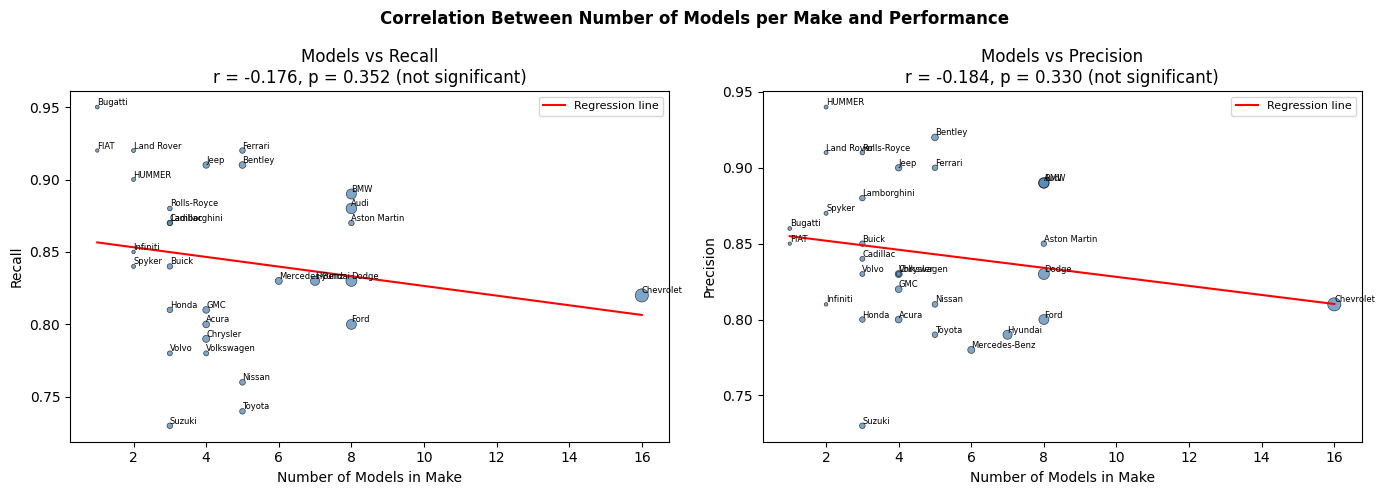

In [11]:
from scipy import stats

# Correlation between num_models and recall/precision
corr_recall, p_recall = stats.pearsonr(df['num_models'], df['recall'])
corr_prec, p_prec = stats.pearsonr(df['num_models'], df['precision'])

print("=== Pearson Correlation with Number of Models ===\n")
print(f"Recall:    r = {corr_recall:.3f}, p = {p_recall:.3f}")
print(f"Precision: r = {corr_prec:.3f}, p = {p_prec:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, corr, p in zip(
    axes,
    ['recall', 'precision'],
    [corr_recall, corr_prec],
    [p_recall, p_prec]
):
    x = df['num_models']
    y = df[metric]

    ax.scatter(x, y,
               s=df['support'] / 10, alpha=0.7,
               edgecolors='black', linewidths=0.5, color='steelblue')

    slope, intercept, _, _, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=1.5, label='Regression line')

    for _, row in df.iterrows():
        ax.annotate(row['class'], (row['num_models'], row[metric]),
                    fontsize=6, ha='left', va='bottom')

    sig = "significant" if p < 0.05 else "not significant"
    ax.set_title(f'Models vs {metric.capitalize()}\nr = {corr:.3f}, p = {p:.3f} ({sig})')
    ax.set_xlabel('Number of Models in Make')
    ax.set_ylabel(metric.capitalize())
    ax.legend(fontsize=8)

plt.suptitle('Correlation Between Number of Models per Make and Performance',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_models_performance.png', dpi=150, bbox_inches='tight')
plt.show()

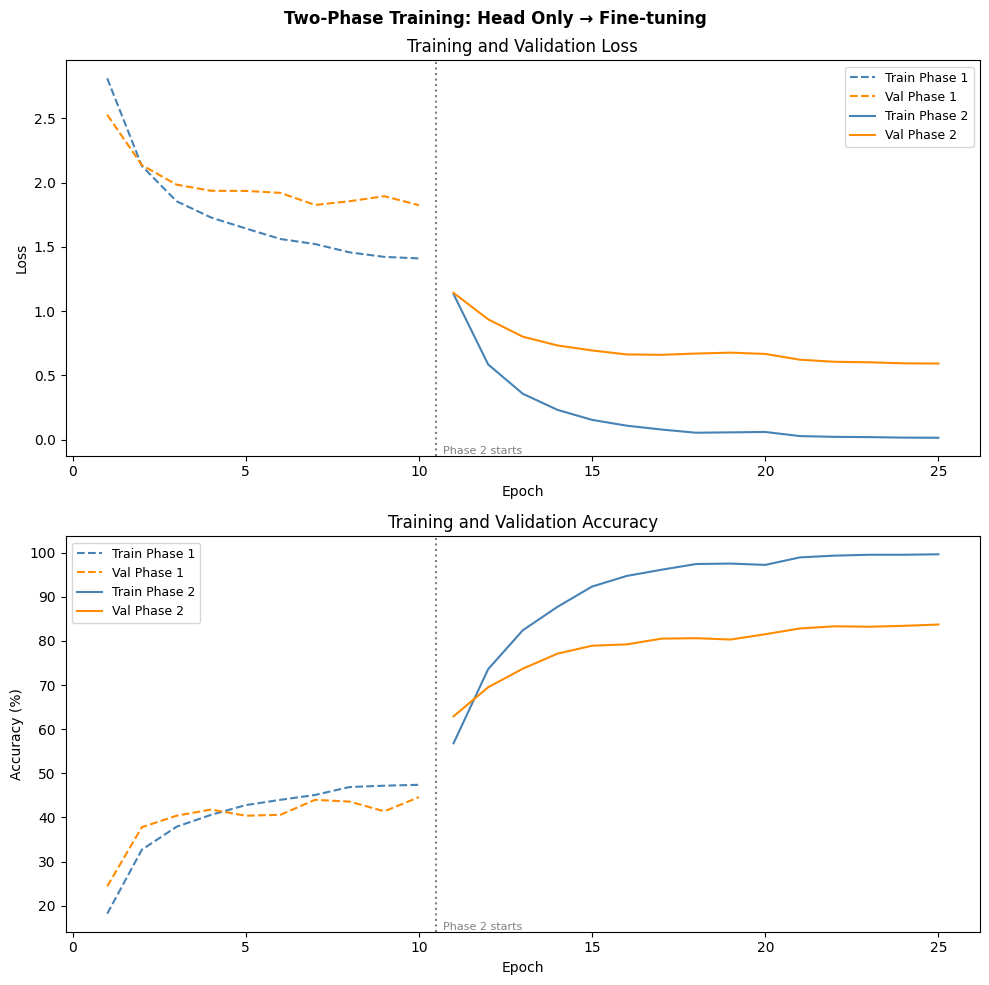

In [14]:
# Phase 1 - Head only training
phase1 = {
    'train_loss': [2.811, 2.129, 1.855, 1.728, 1.643, 1.561, 1.522, 1.457, 1.422, 1.410],
    'val_loss':   [2.528, 2.136, 1.984, 1.936, 1.935, 1.920, 1.826, 1.855, 1.894, 1.824],
    'train_acc':  [18.2, 32.7, 37.9, 40.6, 42.8, 44.0, 45.1, 46.9, 47.2, 47.4],
    'val_acc':    [24.4, 37.8, 40.4, 41.8, 40.4, 40.6, 44.0, 43.6, 41.4, 44.6]
}

# Phase 2 - Fine-tuning
phase2 = {
    'train_loss': [1.132, 0.585, 0.357, 0.232, 0.154, 0.109, 0.079, 0.054, 0.057, 0.060, 0.028, 0.022, 0.020, 0.016, 0.015],
    'val_loss':   [1.142, 0.936, 0.801, 0.733, 0.694, 0.663, 0.660, 0.670, 0.677, 0.667, 0.622, 0.606, 0.602, 0.594, 0.592],
    'train_acc':  [56.8, 73.6, 82.4, 87.7, 92.3, 94.7, 96.1, 97.4, 97.5, 97.2, 98.9, 99.3, 99.5, 99.5, 99.6],
    'val_acc':    [62.9, 69.5, 73.7, 77.1, 78.9, 79.2, 80.5, 80.6, 80.3, 81.5, 82.8, 83.3, 83.2, 83.4, 83.7]
}

p1_epochs = list(range(1, 11))
p2_epochs = list(range(11, 26))

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# --- Loss plot ---
axes[0].plot(p1_epochs, phase1['train_loss'], color='steelblue',  linestyle='--', label='Train Phase 1')
axes[0].plot(p1_epochs, phase1['val_loss'],   color='darkorange', linestyle='--', label='Val Phase 1')
axes[0].plot(p2_epochs, phase2['train_loss'], color='steelblue',  linestyle='-',  label='Train Phase 2')
axes[0].plot(p2_epochs, phase2['val_loss'],   color='darkorange', linestyle='-',  label='Val Phase 2')
axes[0].axvline(x=10.5, color='grey', linestyle=':', linewidth=1.5)
axes[0].text(10.7, axes[0].get_ylim()[0], 'Phase 2 starts', fontsize=8, color='grey', va='bottom')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend(fontsize=9)

# --- Accuracy plot ---
axes[1].plot(p1_epochs, phase1['train_acc'], color='steelblue',  linestyle='--', label='Train Phase 1')
axes[1].plot(p1_epochs, phase1['val_acc'],   color='darkorange', linestyle='--', label='Val Phase 1')
axes[1].plot(p2_epochs, phase2['train_acc'], color='steelblue',  linestyle='-',  label='Train Phase 2')
axes[1].plot(p2_epochs, phase2['val_acc'],   color='darkorange', linestyle='-',  label='Val Phase 2')
axes[1].axvline(x=10.5, color='grey', linestyle=':', linewidth=1.5)
axes[1].text(10.7, axes[1].get_ylim()[0], 'Phase 2 starts', fontsize=8, color='grey', va='bottom')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend(fontsize=9)

plt.suptitle('Two-Phase Training: Head Only → Fine-tuning', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_both_phases.png', dpi=150, bbox_inches='tight')
plt.show()